# Convert and Optimize YOLO26 instance segmentation model with OpenVINO™

Instance segmentation goes a step further than object detection and involves identifying individual objects in an image and segmenting them from the rest of the image. Instance segmentation as an object detection are often used as key components in computer vision systems.
Applications that use real-time instance segmentation models include video analytics, robotics, autonomous vehicles, multi-object tracking and object counting, medical image analysis, and many others.


This tutorial demonstrates step-by-step instructions on how to run and optimize PyTorch YOLO26 with OpenVINO. We consider the steps required for instance segmentation scenario. You can find more details about model on [model page](https://docs.ultralytics.com/models/yolo26/) in Ultralytics documentation.

[YOLO26](https://docs.ultralytics.com/models/yolo26/) brings several enhancements to instance segmentation:
- **Semantic Segmentation Loss** — improved loss function for more accurate mask predictions.
- **Multi-scale Proto Heads** — better feature extraction for segmentation masks across scales.
- **End-to-End NMS-Free Inference** — simplified deployment pipeline.
- **DFL Removal & Dual-Head Architecture** — streamlined export and broader hardware compatibility.
- **Up to 43% Faster CPU Inference** — optimized for edge computing environments.


#### Table of contents:

- [Get PyTorch model](#Get-PyTorch-model)
    - [Prerequisites](#Prerequisites)
- [Instantiate model](#Instantiate-model)
    - [Convert model to OpenVINO IR](#Convert-model-to-OpenVINO-IR)
    - [Verify model inference](#Verify-model-inference)
    - [Select inference device](#Select-inference-device)
    - [Test on single image](#Test-on-single-image)
- [Optimize model using NNCF Post-training Quantization API](#Optimize-model-using-NNCF-Post-training-Quantization-API)
    - [Validate Quantized model inference](#Validate-Quantized-model-inference)
- [Compare performance of the Original and Quantized Models](#Compare-performance-of-the-Original-and-Quantized-Models)
- [Other ways to optimize model](#Other-ways-to-optimize-model)
- [Live demo](#Live-demo)
    - [Run Live Object Detection and Segmentation](#Run-Live-Object-Detection-and-Segmentation)


### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/yolov26-optimization/yolov26-instance-segmentation.ipynb" />

## Get PyTorch model
[back to top ⬆️](#Table-of-contents:)

Generally, PyTorch models represent an instance of the [`torch.nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html) class, initialized by a state dictionary with model weights.
We will use the YOLO26 nano model (also known as `yolo26n-seg`) pre-trained on a COCO dataset, which is available in this [repo](https://github.com/ultralytics/ultralytics). Similar steps are also applicable to other YOLO26 models.
Typical steps to obtain a pre-trained model:
1. Create an instance of a model class.
2. Load a checkpoint state dict, which contains the pre-trained model weights.
3. Turn the model to evaluation for switching some operations to inference mode.

In this case, the creators of the model provide an API that enables converting the YOLO26 model to OpenVINO IR. Therefore, we do not need to do these steps manually.

#### Prerequisites
[back to top ⬆️](#Table-of-contents:)

Install necessary packages.

In [ ]:
import platform

if platform.system() == "Darwin":
    %pip install -q "numpy<2.0.0"


%pip install -qU "openvino>=2026.0.0" "nncf>=3.0.0"
%pip install -q "torch==2.10" torchvision --extra-index-url https://download.pytorch.org/whl/cpu
%pip install -q "ultralytics==8.4.43" tqdm opencv-python Pillow

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Import required utility functions.
The lower cell will download the `notebook_utils` Python module from GitHub.

In [2]:
from pathlib import Path
import requests

if not Path("notebook_utils.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
    )
    open("notebook_utils.py", "w").write(r.text)

from notebook_utils import download_file, VideoPlayer, device_widget, quantization_widget

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("yolov26-instance-segmentation.ipynb")

In [3]:
# Download a test sample
IMAGE_PATH = Path("./data/coco_bike.jpg")

if not IMAGE_PATH.exists():
    download_file(
        url="https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/image/coco_bike.jpg",
        filename=IMAGE_PATH.name,
        directory=IMAGE_PATH.parent,
    )

## Instantiate model
[back to top ⬆️](#Table-of-contents:)

For loading the model, required to specify a path to the model checkpoint. It can be some local path or name available on models hub (in this case model checkpoint will be downloaded automatically).

Making prediction, the model accepts a path to input image and returns list with Results class object. Results contains boxes and masks for instance segmentation. Also it contains utilities for processing results, for example, `plot()` method for drawing.

Let us consider the examples:

In [4]:
import ipywidgets as widgets

model_id = ["yolo26n-seg", "yolo26s-seg", "yolo26m-seg", "yolo26l-seg", "yolo26x-seg"]

model_name = widgets.Dropdown(options=model_id, value=model_id[0], description="Model")

model_name

Dropdown(description='Model', options=('yolo26n-seg', 'yolo26s-seg', 'yolo26m-seg', 'yolo26l-seg', 'yolo26x-se…


image 1/1 /home/maleksandr/test_notebooks/yolov26/openvino_notebooks/notebooks/yolov26-optimization/data/coco_bike.jpg: 480x640 1 bicycle, 2 cars, 1 dog, 112.3ms
Speed: 2.5ms preprocess, 112.3ms inference, 3.8ms postprocess per image at shape (1, 3, 480, 640)


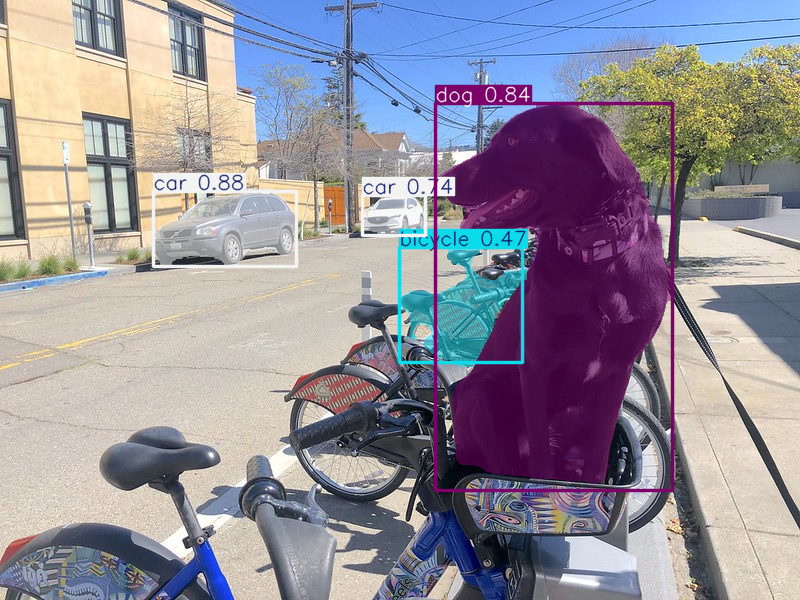

In [5]:
from PIL import Image
from ultralytics import YOLO

SEG_MODEL_NAME = model_name.value

seg_model = YOLO(f"{SEG_MODEL_NAME}.pt")
seg_model.to("cpu")
label_map = seg_model.model.names

res = seg_model(IMAGE_PATH)
Image.fromarray(res[0].plot()[:, :, ::-1])

### Convert model to OpenVINO IR
[back to top ⬆️](#Table-of-contents:)

Ultralytics provides the `model.export()` method for converting models to OpenVINO IR format. Key parameters for YOLO26:

| Parameter | Value | Description |
|-----------|-------|-------------|
| `format` | `"openvino"` | Target export format |
| `half` | `True` | Export weights in FP16 precision for smaller model size and faster inference |
| `dynamic` | `True` / `False` | `dynamic=True` preserves the original preprocessing behavior (adaptive LetterBox padding) and produces results closest to the PyTorch model. `dynamic=False` uses fixed 640×640 input shape — required for NPU deployment and may improve throughput, but can slightly affect detection results due to different padding |
| `end2end` | `True` | **Required for YOLO26.** Exports NMS-free end-to-end model. YOLO26 uses a single one2one detection head (no dual one2many/one2one heads), so `end2end=False` will cause a `KeyError` at export |

> **Note**: Unlike older YOLO versions (v8, v11) that support both `end2end=True` (NMS-free) and `end2end=False` (with external NMS), YOLO26 is architecturally NMS-free and only works with `end2end=True`.

In [6]:
# segmentation model
seg_model_path = Path(f"{SEG_MODEL_NAME}_openvino_model/{SEG_MODEL_NAME}.xml")
if not seg_model_path.exists():
    seg_model.export(format="openvino", dynamic=False, half=True, end2end=True)

### Verify model inference
[back to top ⬆️](#Table-of-contents:)

We can reuse the base model pipeline specifying Intel devices (intel:gpu, intel:npu, intel:cpu) when running inference with OpenVINO.

### Select inference device
[back to top ⬆️](#Table-of-contents:)

Select device from dropdown list for running inference using OpenVINO

In [7]:
device = device_widget()

device

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

### Test on single image
[back to top ⬆️](#Table-of-contents:)

Loading yolo26n-seg_openvino_model for OpenVINO inference...
WARNING ⚠️ OpenVINO device 'AUTO' not available. Using 'AUTO' instead.
Using OpenVINO LATENCY mode for batch=1 inference on CPU...

image 1/1 /home/maleksandr/test_notebooks/yolov26/openvino_notebooks/notebooks/yolov26-optimization/data/coco_bike.jpg: 640x640 1 bicycle, 2 cars, 1 dog, 24.2ms
Speed: 4.5ms preprocess, 24.2ms inference, 7.8ms postprocess per image at shape (1, 3, 640, 640)


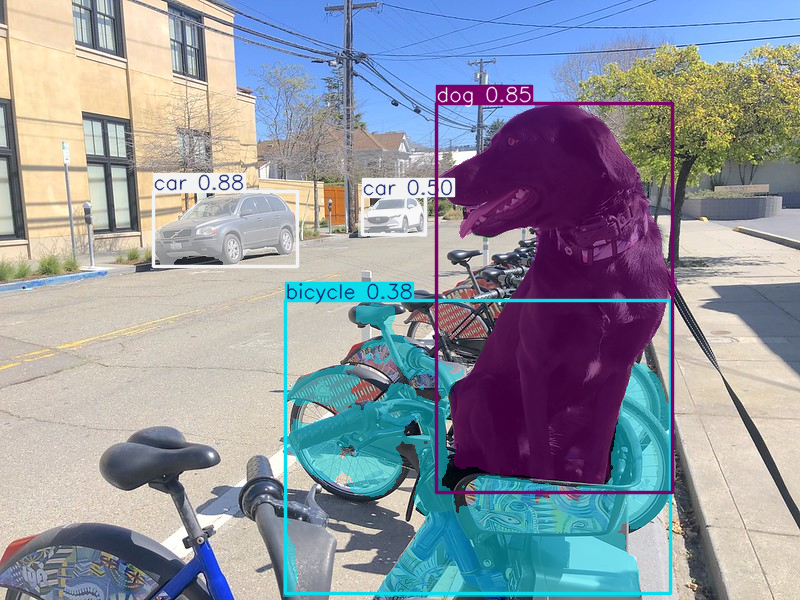

In [8]:
seg_model = YOLO(seg_model_path.parent, task="segment")

res = seg_model(IMAGE_PATH, device=f"intel:{device.value.lower()}")
Image.fromarray(res[0].plot()[:, :, ::-1])

## Optimize model using NNCF Post-training Quantization API
[back to top ⬆️](#Table-of-contents:)

[NNCF](https://github.com/openvinotoolkit/nncf) provides a suite of advanced algorithms for Neural Networks inference optimization in OpenVINO with minimal accuracy drop.
We will use 8-bit quantization in post-training mode (without the fine-tuning pipeline) to optimize YOLO26.

The optimization process contains the following steps:

1. Create a Dataset for quantization.
2. Run `nncf.quantize` for getting an optimized model.
3. Serialize OpenVINO IR model, using the `openvino.save_model` function.

Please select below whether you would like to run quantization to improve model inference speed.

In [9]:
int8_model_seg_path = Path(f"{SEG_MODEL_NAME}_openvino_model_int8/{SEG_MODEL_NAME}.xml")
quantized_seg_model = None

to_quantize = quantization_widget()

to_quantize

Checkbox(value=True, description='Quantization')

Let's load `skip magic` extension to skip quantization if `to_quantize` is not selected

In [10]:
if not Path("skip_kernel_extension.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/skip_kernel_extension.py",
    )
    open("skip_kernel_extension.py", "w").write(r.text)

%load_ext skip_kernel_extension

Prepare calibration dataset for quantization. We download a small dataset and define a transformation function for preprocessing input images.

In [11]:
%%skip not $to_quantize.value

import cv2
import numpy as np
from zipfile import ZipFile
from pathlib import Path
from notebook_utils import use_local_ultralytics_datasets
from ultralytics.data.augment import LetterBox

OUT_DIR = use_local_ultralytics_datasets()

# Using coco128-seg dataset (128 images for better calibration quality)
DATA_URL = "https://ultralytics.com/assets/coco128-seg.zip"
DATA_PATH = OUT_DIR / "coco128-seg.zip"

if not int8_model_seg_path.exists():
    if not (OUT_DIR / "coco128-seg").exists():
        download_file(DATA_URL, DATA_PATH.name, DATA_PATH.parent)
        with ZipFile(DATA_PATH, "r") as zip_ref:
            zip_ref.extractall(OUT_DIR)

    # Get images from coco128-seg (128 images for better calibration quality)
    image_files = list((OUT_DIR / "coco128-seg" / "images" / "train2017").glob("*.jpg"))

    # Prepare transform for NNCF
    def transform_fn(image_path):
        img = cv2.imread(str(image_path))
        img = LetterBox((640, 640))(image=img)
        img = img.transpose(2, 0, 1)  # HWC to CHW
        img = img[::-1]  # BGR to RGB
        img = np.ascontiguousarray(img, dtype=np.float32) / 255.0
        return np.expand_dims(img, 0)

The `nncf.quantize` function provides an interface for model quantization. It requires an instance of the OpenVINO Model and quantization dataset.
Optionally, some additional parameters for the configuration quantization process (number of samples for quantization, preset, ignored scope, etc.) can be provided. Ultralytics models contain non-ReLU activation functions, which require asymmetric quantization of activations. To achieve a better result, we will use a `mixed` quantization preset. It provides symmetric quantization of weights and asymmetric quantization of activations.

Following the [NNCF optimal settings for YOLO26](https://github.com/openvinotoolkit/nncf/tree/develop/examples/post_training_quantization/openvino/yolo26), we also disable `fast_bias_correction` and add the `.*one2one.*` pattern to `ignored_scope` to prevent accuracy degradation in the NMS-free detection head.

>**Note**: Model post-training quantization is a time-consuming process. Be patient, it can take several minutes depending on your hardware.

In [12]:
%%skip not $to_quantize.value

import nncf
import openvino as ov
import shutil

if not int8_model_seg_path.exists():
    core = ov.Core()
    ov_model = core.read_model(seg_model_path)

    quantization_dataset = nncf.Dataset(image_files, transform_fn)

    quantized_seg_model = nncf.quantize(
        ov_model,
        quantization_dataset,
        preset=nncf.QuantizationPreset.MIXED,
        fast_bias_correction=False,
        ignored_scope=nncf.IgnoredScope(patterns=[".*one2one.*"]),
    )
    print(f"Quantized model will be saved to {int8_model_seg_path}")
    ov.save_model(quantized_seg_model, str(int8_model_seg_path))
    shutil.copy(seg_model_path.parent / "metadata.yaml", int8_model_seg_path.parent / "metadata.yaml")

### Validate Quantized model inference
[back to top ⬆️](#Table-of-contents:)

`nncf.quantize` returns the OpenVINO Model class instance, which is suitable for loading on a device for making predictions. `INT8` model input data and output result formats have no difference from the floating point model representation. Therefore, we can reuse the same inference function defined above for getting the `INT8` model result on the image.

Loading yolo26n-seg_openvino_model_int8 for OpenVINO inference...
WARNING ⚠️ OpenVINO device 'AUTO' not available. Using 'AUTO' instead.
Using OpenVINO LATENCY mode for batch=1 inference on CPU...

image 1/1 /home/maleksandr/test_notebooks/yolov26/openvino_notebooks/notebooks/yolov26-optimization/data/coco_bike.jpg: 640x640 1 bicycle, 2 cars, 1 dog, 11.4ms
Speed: 3.1ms preprocess, 11.4ms inference, 5.5ms postprocess per image at shape (1, 3, 640, 640)


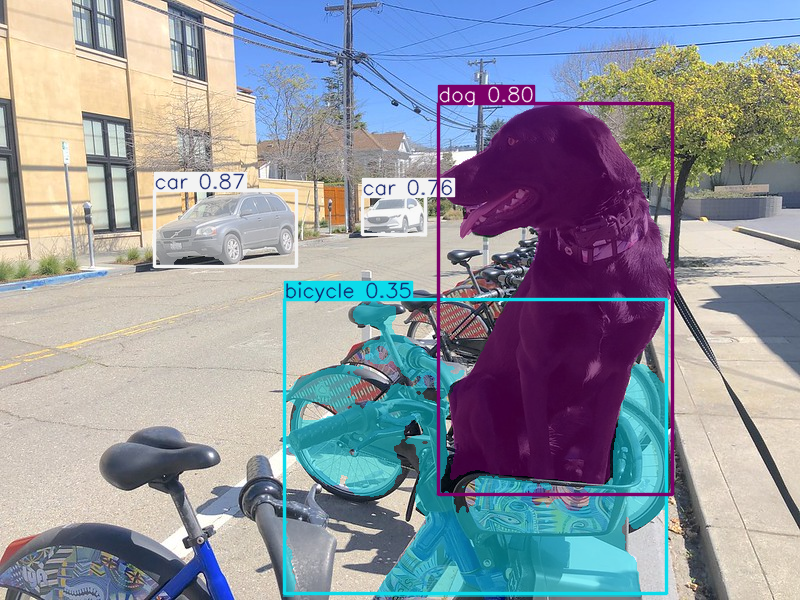

In [13]:
%%skip not $to_quantize.value

seg_model = YOLO(int8_model_seg_path.parent, task="segment")

res = seg_model(IMAGE_PATH, device=f"intel:{device.value.lower()}")
display(Image.fromarray(res[0].plot()[:, :, ::-1]))

## Compare performance of the Original and Quantized Models
[back to top ⬆️](#Table-of-contents:)

Finally, use the OpenVINO [Benchmark Tool](https://docs.openvino.ai/2026/learn-openvino/openvino-samples/benchmark-tool.html) to measure the inference performance of the `FP16` and `INT8` models.

> **Note**: For more accurate performance, it is recommended to run `benchmark_app` in a terminal/command prompt after closing other applications. Run `benchmark_app -m <model_path> -d CPU -shape "<input_shape>"` to benchmark async inference on CPU on specific input data shape for one minute. Change `CPU` to `GPU` to benchmark on GPU. Run `benchmark_app --help` to see an overview of all command-line options.

In [14]:
device

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

In [15]:
# Inference FP16 model (OpenVINO IR)
!benchmark_app -m $seg_model_path -d $device.value -api async -shape "[1,3,640,640]" -t 15

[Step 1/11] Parsing and validating input arguments
[ INFO ] Parsing input parameters
[Step 2/11] Loading OpenVINO Runtime
[ INFO ] OpenVINO:
[ INFO ] Build ................................. 2026.0.0-20965-c6d6a13a886-releases/2026/0
[ INFO ] 
[ INFO ] Device info:
[ INFO ] AUTO
[ INFO ] Build ................................. 2026.0.0-20965-c6d6a13a886-releases/2026/0
[ INFO ] 
[ INFO ] 
[Step 3/11] Setting device configuration
[ WARNING ] Performance hint was not explicitly specified in command line or config file. Device(AUTO) performance hint will be set to PerformanceMode.THROUGHPUT.
[Step 4/11] Reading model files
[ INFO ] Loading model files
[ INFO ] Read model took 19.31 ms
[ INFO ] Original model I/O parameters:
[ INFO ] Model inputs:
[ INFO ]     x (node: x) : f32 / [...] / [1,3,640,640]
[ INFO ] Model outputs:
[ INFO ]     ***NO_NAME*** (node: __module.model.23/aten::cat/Concat_5) : f32 / [...] / [1,300,38]
[ INFO ]     input (node: __module.model.23.proto.feat_fuse.act/aten:

In [16]:
if int8_model_seg_path.exists():
    !benchmark_app -m $int8_model_seg_path -d $device.value -api async -shape "[1,3,640,640]" -t 15

[Step 1/11] Parsing and validating input arguments
[ INFO ] Parsing input parameters
[Step 2/11] Loading OpenVINO Runtime
[ INFO ] OpenVINO:
[ INFO ] Build ................................. 2026.0.0-20965-c6d6a13a886-releases/2026/0
[ INFO ] 
[ INFO ] Device info:
[ INFO ] AUTO
[ INFO ] Build ................................. 2026.0.0-20965-c6d6a13a886-releases/2026/0
[ INFO ] 
[ INFO ] 
[Step 3/11] Setting device configuration
[ WARNING ] Performance hint was not explicitly specified in command line or config file. Device(AUTO) performance hint will be set to PerformanceMode.THROUGHPUT.
[Step 4/11] Reading model files
[ INFO ] Loading model files
[ INFO ] Read model took 44.19 ms
[ INFO ] Original model I/O parameters:
[ INFO ] Model inputs:
[ INFO ]     x (node: x) : f32 / [...] / [1,3,640,640]
[ INFO ] Model outputs:
[ INFO ]     ***NO_NAME*** (node: __module.model.23/aten::cat/Concat_5) : f32 / [...] / [1,300,38]
[ INFO ]     input (node: __module.model.23.proto.feat_fuse.act/aten:

## Other ways to optimize model
[back to top ⬆️](#Table-of-contents:)

The performance could be also improved by another OpenVINO method such as async inference pipeline or preprocessing API.

Async Inference pipeline help to utilize the device more optimal. The key advantage of the Async API is that when a device is busy with inference, the application can perform other tasks in parallel (for example, populating inputs or scheduling other requests) rather than wait for the current inference to complete first. To understand how to perform async inference using openvino, refer to [Async API tutorial](../async-api/async-api.ipynb).

## Live demo
[back to top ⬆️](#Table-of-contents:)

The following code runs model inference on a video:

### Run Live Object Detection and Segmentation
[back to top ⬆️](#Table-of-contents:)

Use a webcam as the video input. By default, the primary webcam is set with `source=0`. If you have multiple webcams, each one will be assigned a consecutive number starting at 0. Set `flip=True` when using a front-facing camera. Some web browsers, especially Mozilla Firefox, may cause flickering. If you experience flickering, set `use_popup=True`.

>**NOTE**: To use this notebook with a webcam, you need to run the notebook on a computer with a webcam. If you run the notebook on a remote server (for example, in Binder or Google Colab service), the webcam will not work. By default, the lower cell will run model inference on a video file. If you want to try live inference on your webcam set `WEBCAM_INFERENCE = True`

In [17]:
import collections
import time
from IPython import display
import cv2
import numpy as np


# Main processing function to run instance segmentation.
def run_instance_segmentation(
    source=0,
    flip=False,
    use_popup=False,
    skip_first_frames=0,
    model=seg_model,
    device=device.value,
    video_width: int = None,  # if not set the original size is used
):
    player = None

    try:
        # Create a video player to play with target fps.
        player = VideoPlayer(source=source, flip=flip, fps=30, skip_first_frames=skip_first_frames)
        # Start capturing.
        player.start()
        if use_popup:
            title = "Press ESC to Exit"
            cv2.namedWindow(winname=title, flags=cv2.WINDOW_GUI_NORMAL | cv2.WINDOW_AUTOSIZE)

        processing_times = collections.deque()
        while True:
            # Grab the frame.
            frame = player.next()
            if frame is None:
                print("Source ended")
                break

            if video_width:
                # If the frame is larger than video_width, reduce size to improve the performance.
                scale = video_width / max(frame.shape)
                frame = cv2.resize(
                    src=frame,
                    dsize=None,
                    fx=scale,
                    fy=scale,
                    interpolation=cv2.INTER_AREA,
                )

            # Get the results.
            input_image = np.array(frame)

            start_time = time.time()
            detections = model(input_image, verbose=False, device=f"intel:{device.lower()}")
            stop_time = time.time()
            frame = detections[0].plot()

            processing_times.append(stop_time - start_time)
            # Use processing times from last 200 frames.
            if len(processing_times) > 200:
                processing_times.popleft()

            _, f_width = frame.shape[:2]
            # Mean processing time [ms].
            processing_time = np.mean(processing_times) * 1000
            fps = 1000 / processing_time
            cv2.putText(
                img=frame,
                text=f"Inference time: {processing_time:.1f}ms ({fps:.1f} FPS)",
                org=(20, 40),
                fontFace=cv2.FONT_HERSHEY_COMPLEX,
                fontScale=f_width / 1000,
                color=(0, 0, 255),
                thickness=1,
                lineType=cv2.LINE_AA,
            )
            # Use this workaround if there is flickering.
            if use_popup:
                cv2.imshow(winname=title, mat=frame)
                key = cv2.waitKey(1)
                # escape = 27
                if key == 27:
                    break
            else:
                # Encode numpy array to jpg.
                _, encoded_img = cv2.imencode(ext=".jpg", img=frame, params=[cv2.IMWRITE_JPEG_QUALITY, 100])
                # Create an IPython image.
                i = display.Image(data=encoded_img)
                # Display the image in this notebook.
                display.clear_output(wait=True)
                display.display(i)
    # ctrl-c
    except KeyboardInterrupt:
        print("Interrupted")
    # any different error
    except RuntimeError as e:
        print(e)
    finally:
        if player is not None:
            # Stop capturing.
            player.stop()
        if use_popup:
            cv2.destroyAllWindows()

In [18]:
WEBCAM_INFERENCE = False

if WEBCAM_INFERENCE:
    VIDEO_SOURCE = 0  # Webcam
else:
    VIDEO_SOURCE = "people.mp4"
    if not Path(VIDEO_SOURCE).exists():
        download_file(
            "https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/video/people.mp4",
            "people.mp4",
        )

In [19]:
device

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

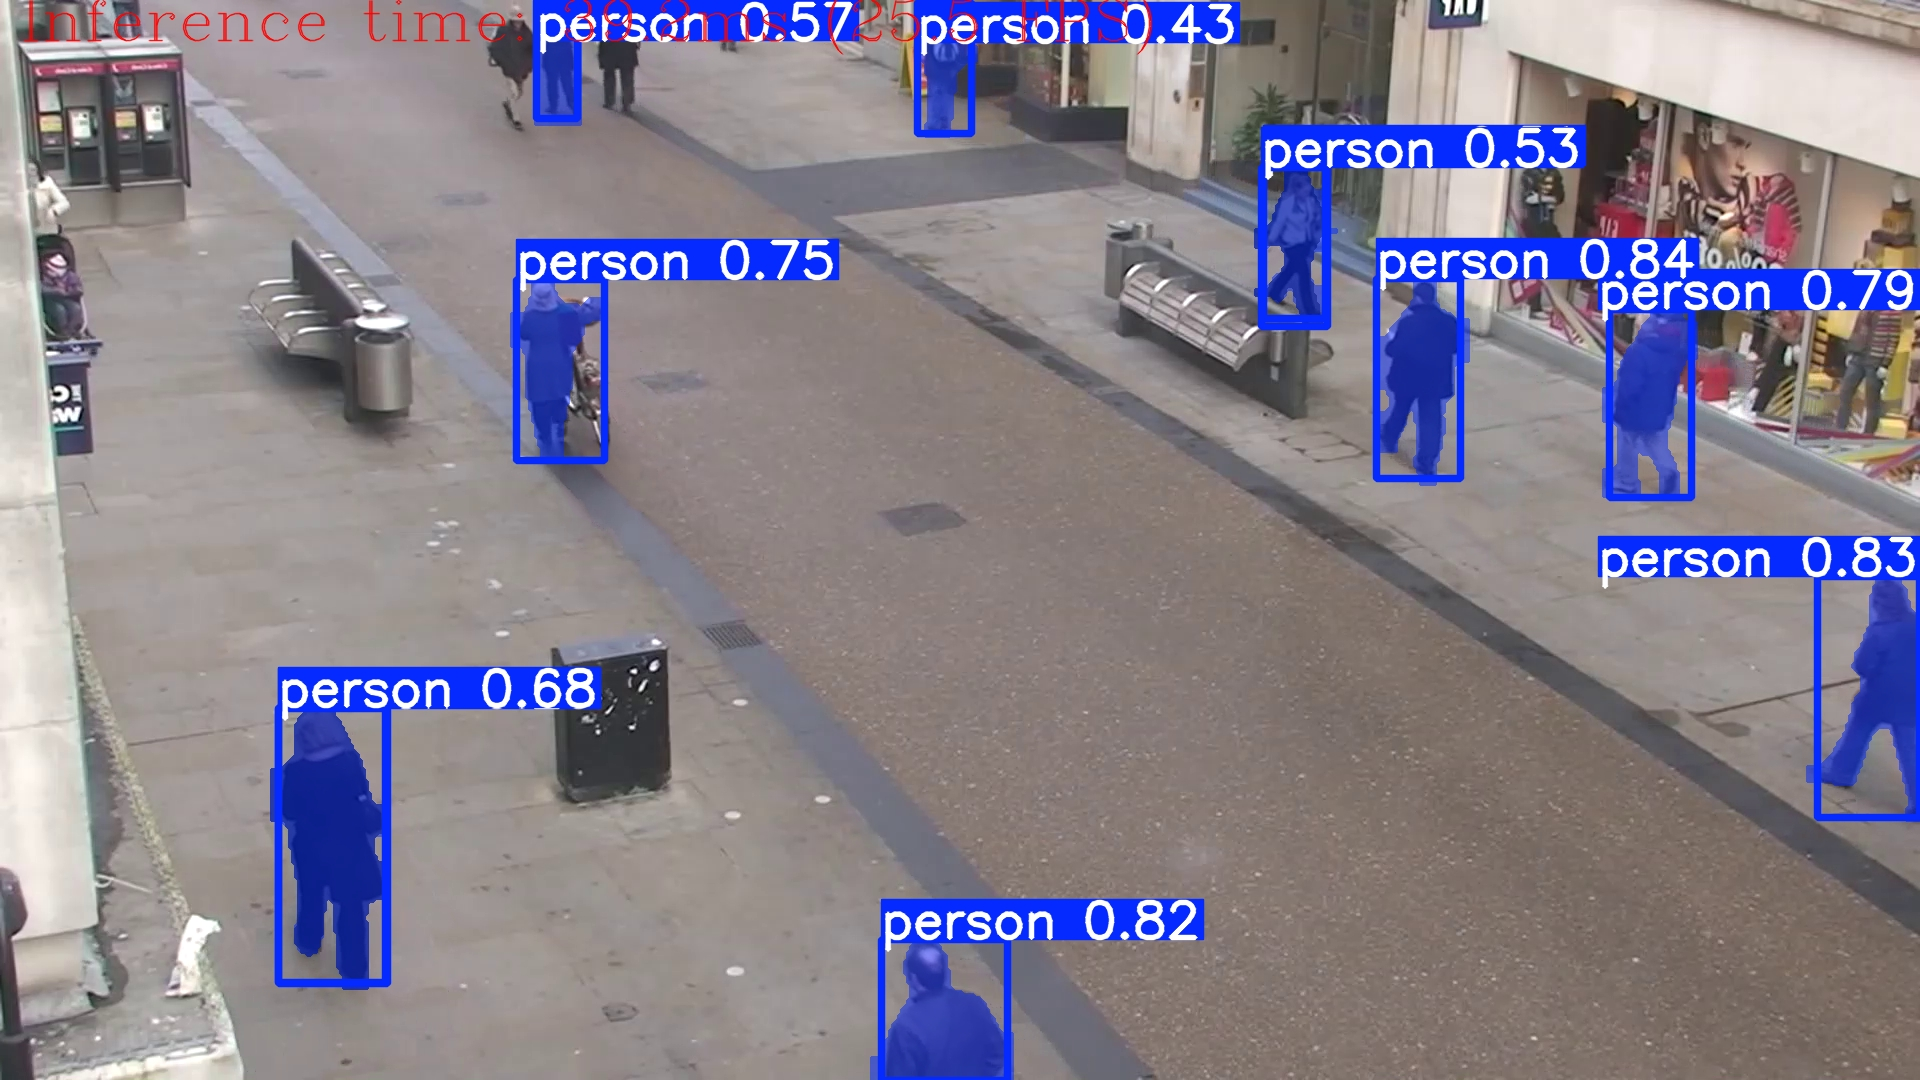

Source ended


In [20]:
run_instance_segmentation(
    source=VIDEO_SOURCE,
    flip=True,
    use_popup=False,
    model=seg_model,
    device=device.value,
)